--- Simple Linear Regression ---
Slope (Coefficient): 2.5518
Intercept: 42.9094
MAE:  13.4795
MSE:  233.9400
RMSE: 15.2951
R^2:  0.6993



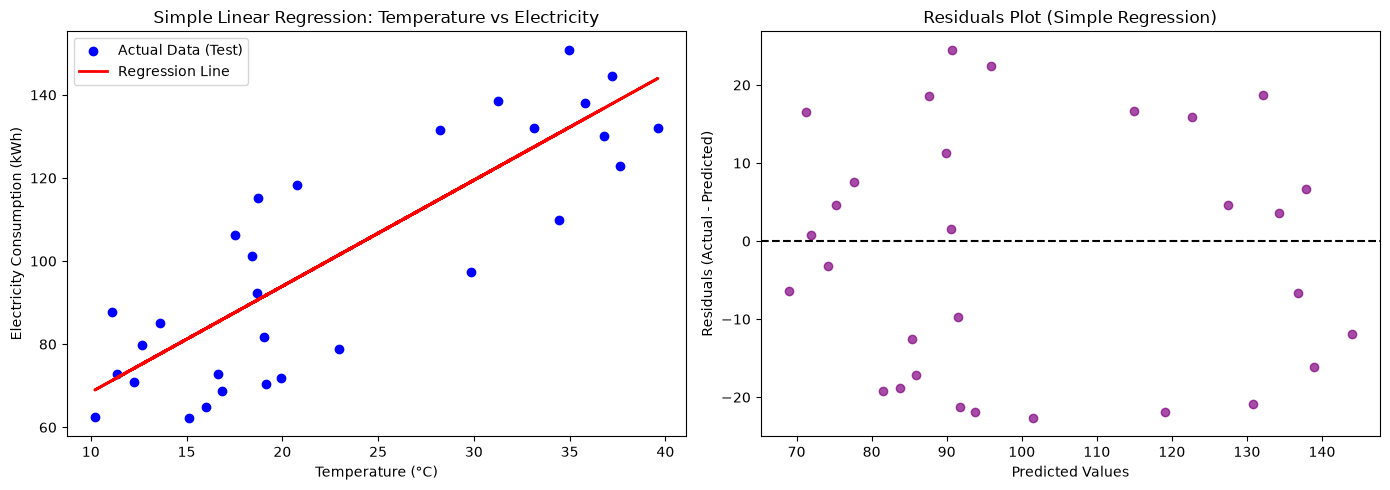

--- Performance Comparison ---
Metric  Simple Regression  Multiple Regression
   MAE          13.479537             3.372894
   MSE         233.939970            18.638903
  RMSE          15.295096             4.317280
   R^2           0.699302             0.976042


--- Effect of Outlier ---
Original Simple Slope: 2.5518 | Intercept: 42.9094
With Outlier Slope:    2.3095 | Intercept: 50.4302


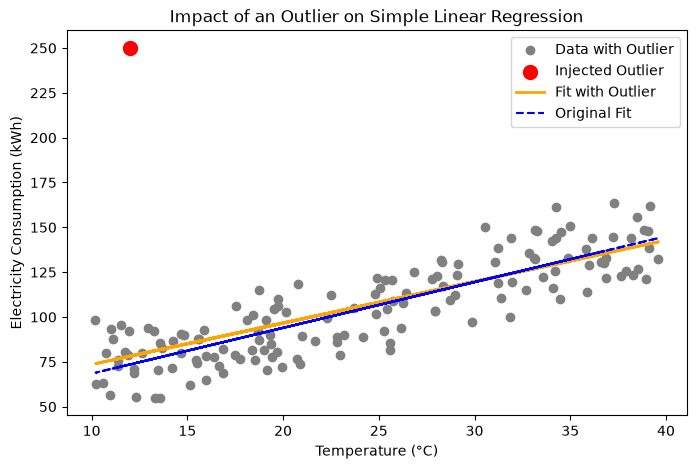

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Create a dataset containing temperature and electricity consumption
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 150

# Temperature in Celsius (e.g., ranging from 10°C to 40°C)
temperature = np.random.uniform(10, 40, n_samples)

# Assume electricity consumption (kWh) has a base load, 
# increases with higher temperatures (AC usage), and includes some random noise.
# Let's also add a second feature: Occupancy (number of people in a building, 1 to 10)
occupancy = np.random.randint(1, 10, n_samples)
electricity = 20 + 2.5 * temperature + 5.0 * occupancy + np.random.normal(0, 5, n_samples)

df = pd.DataFrame({
    'Temperature': temperature,
    'Occupancy': occupancy,
    'Electricity': electricity
})

# ---------------------------------------------------------
# 2. Train a simple linear regression model (Feature: Temperature)
# ---------------------------------------------------------
X_simple = df[['Temperature']]
y = df['Electricity']

# 3. Divide the data into training and testing sets (80% train, 20% test)
X_train_s, X_test_s, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

# 4. Print the slope and intercept
print("--- Simple Linear Regression ---")
print(f"Slope (Coefficient): {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.4f}")

# 5. Calculate MAE, MSE, RMSE, and R^2 on test data
y_pred_s = simple_model.predict(X_test_s)
mae_s = mean_absolute_error(y_test, y_pred_s)
mse_s = mean_squared_error(y_test, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test, y_pred_s)

print(f"MAE:  {mae_s:.4f}")
print(f"MSE:  {mse_s:.4f}")
print(f"RMSE: {rmse_s:.4f}")
print(f"R^2:  {r2_s:.4f}\n")

# 6. Plot the regression line and 7. Plot residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression Line Plot
axes[0].scatter(X_test_s, y_test, color='blue', label='Actual Data (Test)')
axes[0].plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Regression Line')
axes[0].set_title('Simple Linear Regression: Temperature vs Electricity')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Electricity Consumption (kWh)')
axes[0].legend()

# Residuals Plot
residuals_s = y_test - y_pred_s
axes[1].scatter(y_pred_s, residuals_s, color='purple', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Plot (Simple Regression)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Add another input feature and train a multiple regression model
# ---------------------------------------------------------
X_multi = df[['Temperature', 'Occupancy']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

y_pred_m = multi_model.predict(X_test_m)

# ---------------------------------------------------------
# 9. Compare simple and multiple regression performance
# ---------------------------------------------------------
mae_m = mean_absolute_error(y_test_m, y_pred_m)
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print("--- Performance Comparison ---")
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R^2'],
    'Simple Regression': [mae_s, mse_s, rmse_s, r2_s],
    'Multiple Regression': [mae_m, mse_m, rmse_m, r2_m]
})
print(comparison_df.to_string(index=False))
print("\n")

# ---------------------------------------------------------
# 10. Investigate the effect of adding an outlier
# ---------------------------------------------------------
df_outlier = df.copy()
outlier_index = 0
df_outlier.loc[outlier_index, 'Temperature'] = 12.0
df_outlier.loc[outlier_index, 'Electricity'] = 250.0  # Massive spike

X_out = df_outlier[['Temperature']]
y_out = df_outlier['Electricity']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_out, y_out, test_size=0.2, random_state=42)

outlier_model = LinearRegression()
outlier_model.fit(X_train_o, y_train_o)

print("--- Effect of Outlier ---")
print(f"Original Simple Slope: {simple_model.coef_[0]:.4f} | Intercept: {simple_model.intercept_:.4f}")
print(f"With Outlier Slope:    {outlier_model.coef_[0]:.4f} | Intercept: {outlier_model.intercept_:.4f}")

# Plotting the impact of the outlier
y_pred_o = outlier_model.predict(X_test_o)
plt.figure(figsize=(8, 5))
plt.scatter(X_out['Temperature'], y_out, color='gray', label='Data with Outlier')
plt.scatter(df_outlier.loc[outlier_index, 'Temperature'], 
            df_outlier.loc[outlier_index, 'Electricity'], 
            color='red', s=100, label='Injected Outlier', zorder=5)
plt.plot(X_test_o, y_pred_o, color='orange', linewidth=2, label='Fit with Outlier')
plt.plot(X_test_s, y_pred_s, color='blue', linestyle='--', label='Original Fit')
plt.title('Impact of an Outlier on Simple Linear Regression')
plt.xlabel('Temperature (°C)')
plt.ylabel('Electricity Consumption (kWh)')
plt.legend()
plt.show()

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Create the dataset
data = {
    'Hours_Studied': [2, 4, 6, 8, 10],
    'Classes_Attended': [3, 4, 5, 6, 8],
    'Final_Score': [65, 70, 75, 85, 95]
}

df = pd.DataFrame(data)

# 2. Separate features (X) and target (y)
X = df[['Hours_Studied', 'Classes_Attended']]
y = df['Final_Score']

# 3. Train the Ordinary Least Squares (OLS) model
model = LinearRegression()
model.fit(X, y)

# Print model parameters
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficients (Hours Studied, Classes Attended): {model.coef_}")

# 4. Predict for the new student (7 hours studied, 5 classes attended)
new_student = pd.DataFrame([[7, 5]], columns=['Hours_Studied', 'Classes_Attended'])
prediction = model.predict(new_student)[0]

print(f"Predicted Final Score: {prediction:.2f}")

Intercept: 47.50
Coefficients (Hours Studied, Classes Attended): [0.75 5.  ]
Predicted Final Score: 77.75


--- Descriptive Statistics ---
       Study_Hours  Attendance  Assignment_Avg  Internal_Mark  Sleep_Duration  \
count   499.000000  499.000000      500.000000     500.000000      500.000000   
mean     12.027538   82.200253       76.215484      70.372986        6.987827   
std       3.891118    9.492838       11.936634      14.452623        1.146834   
min       2.000000   55.031134       40.244935      25.894170        4.000000   
25%       9.196443   76.153571       67.770845      60.820958        6.207116   
50%      12.050370   82.287448       76.437670      69.866300        6.996217   
75%      14.558590   88.522834       84.056860      80.496541        7.803012   
max      25.000000  100.000000      100.000000     100.000000       10.731902   

       Final_Mark  
count  500.000000  
mean    76.126397  
std      8.775899  
min     48.207593  
25%     70.401928  
50%     75.692649  
75%     81.757272  
max    100.000000  

--- Missing Values Before Imputation ---
Study_Hours      

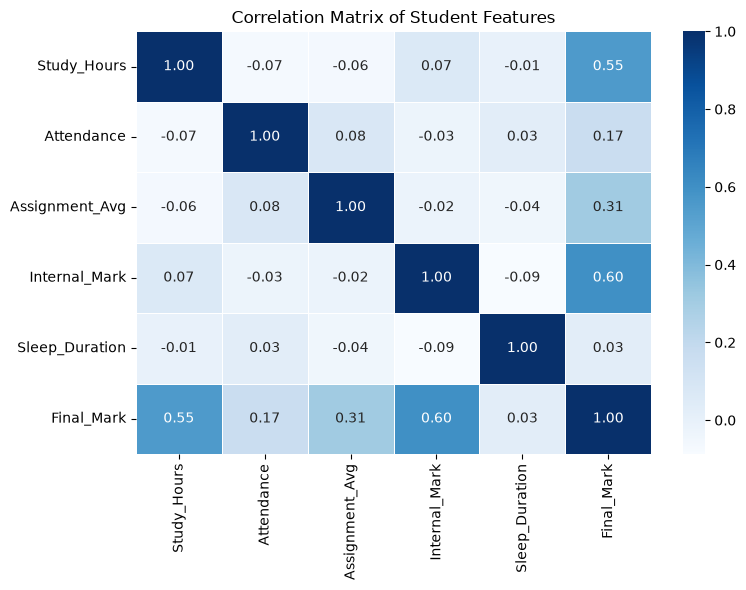


--- Model Evaluation Results ---
MAE:          3.0068
MSE:          14.4012
RMSE:         3.7949
R^2:          0.8187
Adjusted R^2: 0.8091


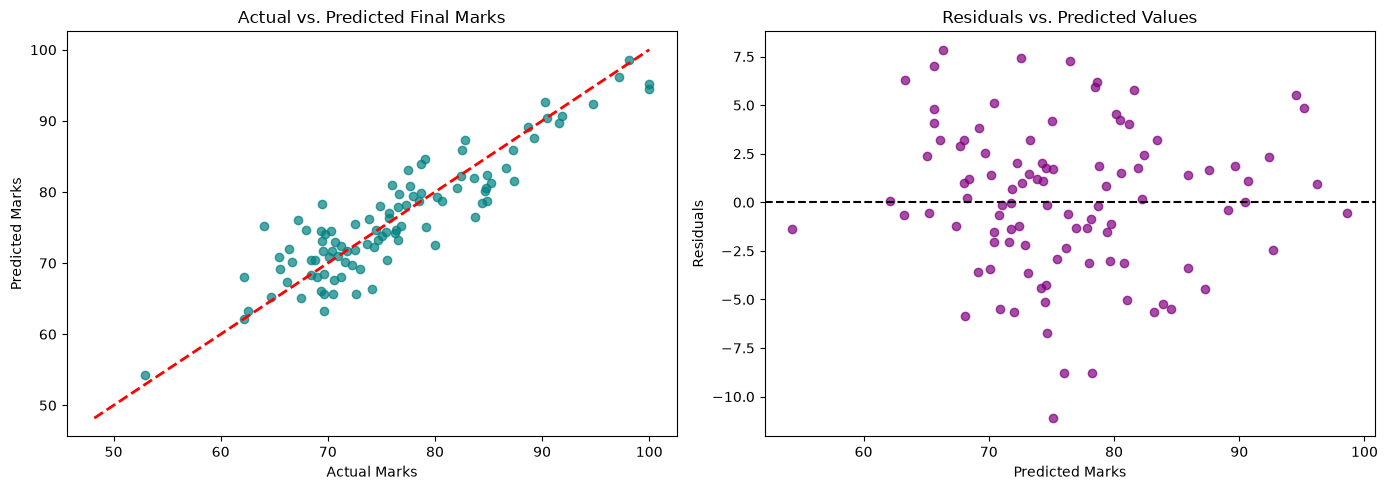


--- Coefficient Interpretations ---
       Feature  Coefficient
   Study_Hours     1.228038
    Attendance     0.159235
Assignment_Avg     0.260686
 Internal_Mark     0.358923
Sleep_Duration     0.624890
Intercept: -1.2427


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Dataset Generation / Import (Cleaned version without NaNs in critical splits)
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 500

# Simulating realistic student attributes
study_hours = np.random.normal(12, 4, n_samples).clip(2, 25)
attendance = np.random.normal(82, 10, n_samples).clip(40, 100)
assignment_avg = np.random.normal(75, 12, n_samples).clip(30, 100)
internal_mark = np.random.normal(70, 15, n_samples).clip(20, 100)
sleep_duration = np.random.normal(7, 1.2, n_samples).clip(4, 11)

# Target: Final Mark derived with weights and minor noise
final_mark = (
    1.2 * study_hours +
    0.15 * attendance +
    0.25 * assignment_avg +
    0.35 * internal_mark +
    0.8 * sleep_duration +
    np.random.normal(0, 4, n_samples)
).clip(0, 100)

df = pd.DataFrame({
    'Study_Hours': study_hours,
    'Attendance': attendance,
    'Assignment_Avg': assignment_avg,
    'Internal_Mark': internal_mark,
    'Sleep_Duration': sleep_duration,
    'Final_Mark': final_mark
})

# Safely inject missing values into temporary copies or handle them explicitly before splitting
df.loc[12, 'Study_Hours'] = np.nan
df.loc[45, 'Attendance'] = np.nan

# Save dataset to CSV
df.to_csv('student_performance.csv', index=False)

# ---------------------------------------------------------
# 2. Descriptive Analysis & 3. Missing Value Check
# ---------------------------------------------------------
print("--- Descriptive Statistics ---")
print(df.describe())
print("\n--- Missing Values Before Imputation ---")
print(df.isnull().sum())

# Handle missing values using median imputation explicitly on the dataframe
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].median())
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())

print("\n--- Missing Values After Imputation ---")
print(df.isnull().sum())

# ---------------------------------------------------------
# 4. Visualize Correlations
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Student Features')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Separate Inputs and Output & 6. Train-Test Split
# ---------------------------------------------------------
X = df[['Study_Hours', 'Attendance', 'Assignment_Avg', 'Internal_Mark', 'Sleep_Duration']]
y = df['Final_Mark']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 7. Train a Multiple Linear Regression Model
# ---------------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 8. Evaluate Model (MAE, RMSE, R^2, Adjusted R^2)
# ---------------------------------------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Calculate Adjusted R^2
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("\n--- Model Evaluation Results ---")
print(f"MAE:          {mae:.4f}")
print(f"MSE:          {mse:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"R^2:          {r2:.4f}")
print(f"Adjusted R^2: {adj_r2:.4f}")

# ---------------------------------------------------------
# 9. Plot Actual versus Predicted Marks & 10. Residuals
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='teal', alpha=0.7)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
axes[0].set_title('Actual vs. Predicted Final Marks')
axes[0].set_xlabel('Actual Marks')
axes[0].set_ylabel('Predicted Marks')

# Residuals Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='purple', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Marks')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 11. Interpret the Coefficients
# ---------------------------------------------------------
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("\n--- Coefficient Interpretations ---")
print(coefficients_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.4f}")